### Canada Per Capita Income Prediction

This project uses a Canada per capita income dataset from Kaggle to predict **per capita income based on year** using a **Linear Regression** model. The relationship between year and per capita income was visualized using a scatter plot and regression line. The model currently achieves an **R² score of 92%**. I also observed that increasing the test set size resulted in a higher R² score, while decreasing the test set size resulted in a lower R² score.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
#Upload dataset
df = pd.read_csv("canada_per_capita_income.csv")
df

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


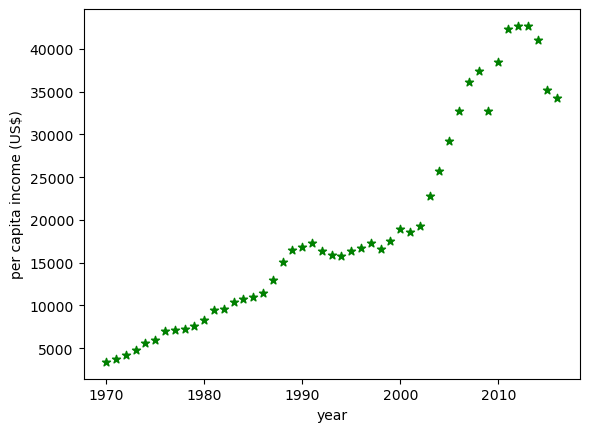

In [3]:
#Scatter plot
%matplotlib inline
plt.xlabel('year')
plt.ylabel('per capita income (US$)')
df = df.rename(columns={'per capita income (US$)':'per_capita_income'})
plt.scatter(df.year, df.per_capita_income, color = 'green', marker = '*')

In [4]:
#Trainer
reg = linear_model.LinearRegression()
reg.fit(df[['year']],df['per_capita_income'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
#predict
reg.predict([[2000]])

C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([24719.39258996])

In [6]:
#Checking
reg.coef_

array([828.46507522])

In [7]:
reg.intercept_

np.float64(-1632210.7578554575)

In [8]:
(828.46507522*2000)-1632210.7578554575

24719.39258454251

In [9]:
#Checking with one of the numbers that it was trained on
reg.predict([[1996]])

C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([21405.53228907])

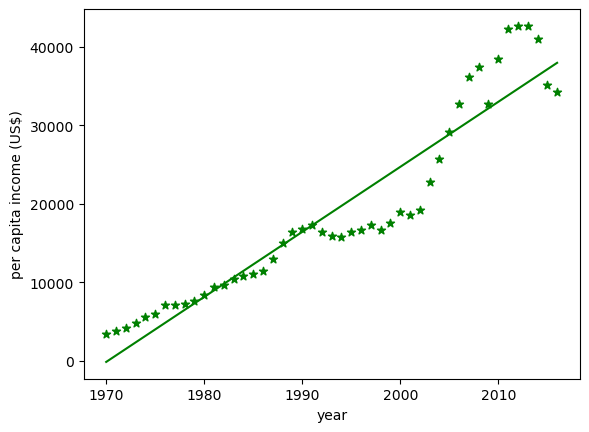

In [10]:
#Buildign scatter plot with line
%matplotlib inline
plt.xlabel('year')
plt.ylabel('per capita income (US$)')
plt.scatter(df.year, df.per_capita_income, color='green', marker='*')
plt.plot(df['year'],reg.predict(df[['year']]), color='green')

Predict new data

In [11]:
#reading input from csv
dfp = pd.read_csv("input_years.csv")
dfp

,year
0,2000
1,2001
2,2002
3,2003
4,2004
5,2005
6,2006
7,2007
8,2008
9,2009


Save predictions into new csv

In [12]:
p = reg.predict(dfp[['year']])
dfp['per capita income (US$)'] = p
dfp.to_csv("prediction_per_capita_income.csv", index=False)

training and test 

In [23]:
from sklearn.model_selection import train_test_split
X = df.drop('per_capita_income', axis =1 ) 
y = df['per_capita_income']

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.2, random_state = 10)

In [26]:
reg.fit(X_train,y_train)
print(len(X_train))
print(len(X_test))

37
10


#Observation:
predict output seems to be close to the actual output

In [29]:
reg.predict(X_test)

array([28308.87945405, 18589.96261535, 33168.3378734 , 31548.51840028,
       35598.06708307, 16160.23340568,  2391.76788419, 24259.33077126,
        5631.40683042,  4821.49709387])

In [27]:
y_test

35    29198.055690
23    15875.586730
41    42334.711210
39    32755.176820
44    41039.893600
20    16838.673200
3      4804.463248
30    18987.382410
7      7100.126170
6      7062.131392
Name: per_capita_income, dtype: float64

## 90 percent accurarcy

In [34]:
reg_accurarcy_r2 = reg.score(X_test, y_test)
reg_accurarcy_r2

0.9063173168991836

test: lower test_size
Observations: accurarcy lowered

In [35]:

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.15, random_state = 10)
reg_accurarcy_r2 = reg.score(X_test, y_test)
print(f"85/15", reg_accurarcy)

85/15 0.8719882120531401


In [38]:

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.10, random_state = 10)
reg_accurarcy_r2 = reg.score(X_test, y_test)
print(f"90/10", reg_accurarcy)

90/10 0.730101292139703


test: raise test_size
Observations: accurarcy raised

In [39]:

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.30, random_state = 10)
reg_accurarcy_r2 = reg.score(X_test, y_test)
print(f"70/30", reg_accurarcy)

70/30 0.9027233076556059


In [40]:

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.35, random_state = 10)
reg_accurarcy_r2 = reg.score(X_test, y_test)
print(f"65/35", reg_accurarcy)

70/30 0.9028087752501823


In [42]:

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.40, random_state = 10)
reg_accurarcy_r2 = reg.score(X_test, y_test)
print(f"60/40", reg_accurarcy)

60/40 0.8969446847237158


In [45]:

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.26, random_state = 10)
reg_accurarcy_r2 = reg.score(X_test, y_test)
print(f"74/26", reg_accurarcy)

60/40 0.9133400818652815


## 92 percent accurarcy

In [49]:

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.25, random_state = 10)
reg_accurarcy_r2 = reg.score(X_test, y_test)
print(f"75/25", reg_accurarcy)

60/40 0.9227031027040955


In [54]:

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.21, random_state = 10)
reg_accurarcy_r2 = reg.score(X_test, y_test)
print(f"79/21", reg_accurarcy)

60/40 0.9063173168991836


In [57]:

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.50, random_state = 10)
reg_accurarcy_r2 = reg.score(X_test, y_test)
print(f"50/50", reg_accurarcy)

60/40 0.8833492790324871
